In [2]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [15]:
df = pd.read_csv("data.csv")

print(df.head())
print(df.columns)

         DATE    Value
0  01-01-1985  72.5052
1  02-01-1985  70.6720
2  03-01-1985  62.4502
3  04-01-1985  57.4714
4  05-01-1985  55.3151
Index(['DATE', 'Value'], dtype='object')


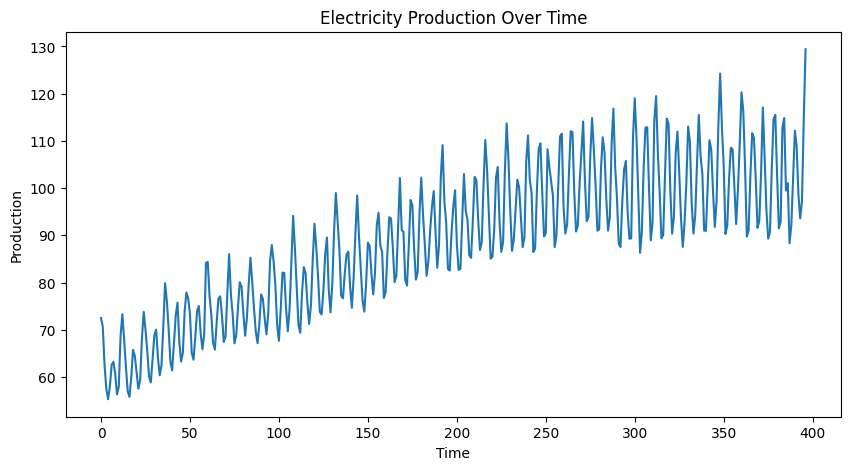

In [ ]:
#Data Visualization
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:, 1])
plt.title("Electricity Production Over Time")
plt.xlabel("Time")
plt.ylabel("Production")
plt.show()

In [18]:
#Preprocessing
data = df.iloc[:, 1].values.reshape(-1, 1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 24
X, y = create_sequences(data_scaled, SEQ_LEN)

# Time-based split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

In [19]:
#RNN Model
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

In [20]:
#LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [21]:
#GRU
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [22]:
#Vision Transformer (adapted for time series)
class SimpleViT(nn.Module):
    def __init__(self, seq_len=24, dim=64, heads=4, layers=2):
        super().__init__()
        self.embedding = nn.Linear(1, dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)

        self.fc = nn.Linear(dim, 1)

    def forward(self, x):
        x = self.embedding(x)           # (batch, seq, dim)
        x = x.permute(1, 0, 2)          # (seq, batch, dim)
        x = self.transformer(x)
        x = x[-1]                       # last token
        return self.fc(x)

In [10]:
#Training Function
def train_model(model, train_loader, epochs=10):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

    return model

In [11]:
#Evaluation
def evaluate(model):
    model.eval()
    with torch.no_grad():
        preds = model(X_test).numpy()
    
    preds = scaler.inverse_transform(preds)
    actual = scaler.inverse_transform(y_test.numpy())

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)

    return rmse, mae, actual, preds

In [12]:
#Train All Models
models = {
    "RNN": RNNModel(),
    "LSTM": LSTMModel(),
    "GRU": GRUModel(),
    "ViT": SimpleViT()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model = train_model(model, train_loader, epochs=10)
    rmse, mae, actual, preds = evaluate(model)
    
    results[name] = (rmse, mae)
    print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}")

/Users/mehakpreetkaur/Library/Python/3.9/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Training RNN...
RNN -> RMSE: 9.3194, MAE: 7.7749
Training LSTM...
LSTM -> RMSE: 10.9181, MAE: 8.8950
Training GRU...
GRU -> RMSE: 12.7986, MAE: 10.1023
Training ViT...
ViT -> RMSE: 8.5822, MAE: 7.1625


In [13]:
#Compare Results
for model, (rmse, mae) in results.items():
    print(f"{model}: RMSE={rmse:.4f}, MAE={mae:.4f}")

RNN: RMSE=9.3194, MAE=7.7749
LSTM: RMSE=10.9181, MAE=8.8950
GRU: RMSE=12.7986, MAE=10.1023
ViT: RMSE=8.5822, MAE=7.1625


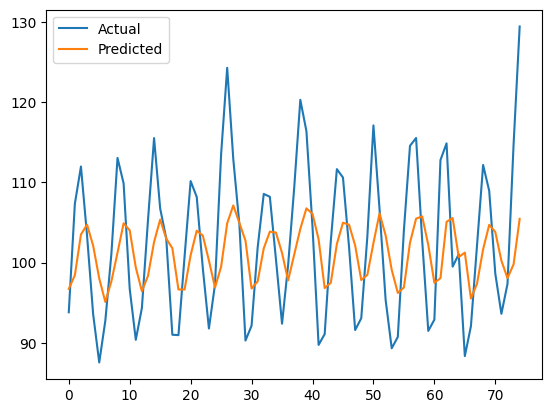

In [14]:
#Plot Predictions
plt.plot(actual, label="Actual")
plt.plot(preds, label="Predicted")
plt.legend()
plt.show()